In [1]:
import numpy as np
import scipy
import torch
import torch.nn as nn
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import matplotlib.pyplot as plt

import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.3, 1.5]

In [3]:
models = [ChebyKAN([2, 10, 2], 4) for i in range(10)]

In [4]:
kanODEs = [KANODE(models[i-1], pred_prey_deriv, X0, params, 30, 2+i, 170) for i in range(1, 11)]

In [5]:
for kan in kanODEs:
    kan.train(1100)

100%|██████████| 1100/1100 [36:01<00:00,  1.96s/it]


Text(0.5, 1.0, 'Test loss of models with differing size of training data')

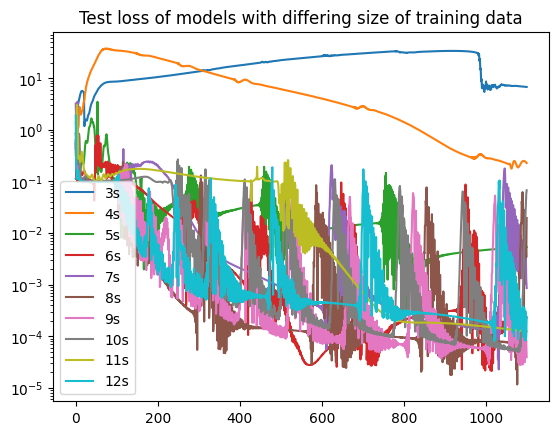

In [6]:
fig, ax = plt.subplots()

for kan in kanODEs:
    ax.semilogy(torch.Tensor(kan.testLossArray), label=f'{kan.trainingTime}s')
ax.legend()
ax.set_title("Test loss of models with differing size of training data")